### Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Torchvision
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os

# Utilities
from tqdm import tqdm

print(torch.__version__)

2.5.1


In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

Using device: cpu
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


### Prepare Data

Train images: 200
Test images: 200
torch.Size([3, 321, 481])


(np.float64(-0.5), np.float64(480.5), np.float64(320.5), np.float64(-0.5))

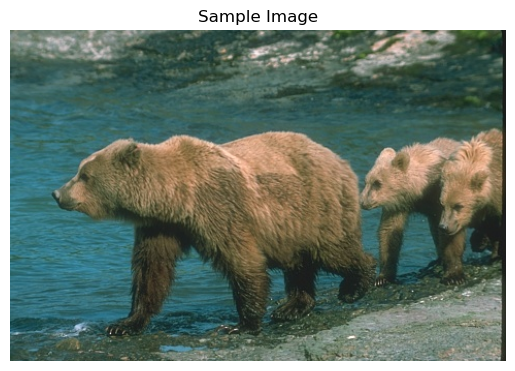

In [6]:
# Load dataset 

transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

train_base = ImageFolder(
    root="./data/BSD500/train",
    transform=transform
)

test_base = ImageFolder(
    root="./data/BSD500/test",
    transform=transform
)

print("Train images:", len(train_base))
print("Test images:", len(test_base))

img, _ = train_base[0]
print(img.shape)

plt.imshow(img.permute(1, 2, 0))
plt.title("Sample Image")
plt.axis('off')

Bayer Mosaic Function

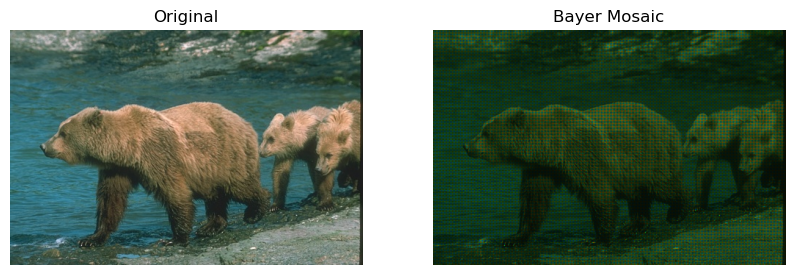

In [7]:
def bayer_mosaic(img):
    """
    img: tensor [3, H, W]
    returns: mosaiced tensor [3, H, W] with zeros in missing channels
    """
    mosaic = torch.zeros_like(img)

    # R channel
    mosaic[0, 0::2, 0::2] = img[0, 0::2, 0::2]

    # G channel
    mosaic[1, 0::2, 1::2] = img[1, 0::2, 1::2]
    mosaic[1, 1::2, 0::2] = img[1, 1::2, 0::2]

    # B channel
    mosaic[2, 1::2, 1::2] = img[2, 1::2, 1::2]

    return mosaic

# Visualize Mosaic vs Original
img, _ = train_base[0]
mosaic = bayer_mosaic(img)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img.permute(1, 2, 0))
ax[0].set_title("Original")

ax[1].imshow(mosaic.permute(1, 2, 0))
ax[1].set_title("Bayer Mosaic")

for a in ax:
    a.axis('off')

Patch Extraction Function

In [ ]:
# This function is being redundant now (never called)
def extract_patches(img, patch_size=33, stride=16):
    """
    img: tensor [3, H, W]
    returns list of patches [3, patch_size, patch_size]
    """
    patches = []
    _, H, W = img.shape

    for i in range(0, H - patch_size + 1, stride): 
        for j in range(0, W - patch_size + 1, stride):
            patch = img[:, i:i+patch_size, j:j+patch_size]
            patches.append(patch)

    return patches

Build Patch Dataset

In [10]:
class DemosaicDataset(Dataset):
    def __init__(self, base_dataset, max_images=None, patch_size=33, stride=16):
        self.images = []
        self.mosaics = []
        self.patch_size = patch_size
        self.stride = stride
        self.index_map = []

        if max_images is None:
            max_images = len(base_dataset)

        # Load images
        for idx in range(max_images):
            img, _ = base_dataset[idx]
            self.images.append(img)
            self.mosaics.append(bayer_mosaic(img))

        # Build index map (image_idx, i, j)
        for img_idx, img in enumerate(self.images):
            _, H, W = img.shape

            for i in range(0, H - patch_size + 1, stride):
                for j in range(0, W - patch_size + 1, stride):
                    self.index_map.append((img_idx, i, j))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        img_idx, i, j = self.index_map[idx]

        inp = self.mosaics[img_idx][:, i:i+self.patch_size, j:j+self.patch_size]
        tgt = self.images[img_idx][:, i:i+self.patch_size, j:j+self.patch_size]

        return inp, tgt
    
# Create Dataset
train_dataset = DemosaicDataset(train_base, max_images=len(train_base))

Input shape: torch.Size([32, 3, 33, 33])
Target shape: torch.Size([32, 3, 33, 33])


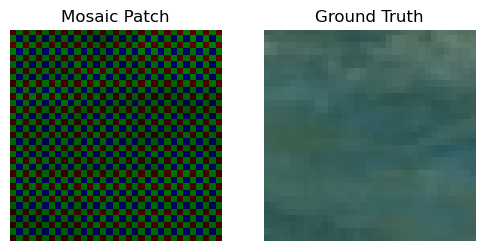

In [15]:
# Dataloader 
train_loader = DataLoader(
train_dataset,
batch_size=32,
shuffle=True,
num_workers=0
)

inputs, targets = next(iter(train_loader))

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)

# Visualize Patch Pair
idx = 0
inp = inputs[idx]
tgt = targets[idx]

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(inp.permute(1, 2, 0))
ax[0].set_title("Mosaic Patch")

ax[1].imshow(tgt.permute(1, 2, 0))
ax[1].set_title("Ground Truth")

for a in ax:
    a.axis('off')

### DMCNN Model

In [16]:
class DMCNN(nn.Module):
    def __init__(self):
        super(DMCNN, self).__init__()

        # Layer 1: Feature extraction
        self.conv1 = nn.Conv2d(3, 128, kernel_size=9, padding=0)

        # Layer 2: Non-linear mapping
        self.conv2 = nn.Conv2d(128, 64, kernel_size=1, padding=0)

        # Layer 3: Reconstruction
        self.conv3 = nn.Conv2d(64, 3, kernel_size=5, padding=0)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

# Instantiate Model
model = DMCNN().to(device)

In [17]:
# Loss & Optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Target Cropping Function
def center_crop(tensor, size=21):
    _, _, h, w = tensor.shape
    start = (h - size) // 2
    end = start + size
    return tensor[:, :, start:end, start:end]

Training Loop

Epoch 1/10: 100%|██████████| 3444/3444 [03:30<00:00, 16.34it/s, loss=0.000334]


Epoch 1 Loss: 0.002590


Epoch 2/10: 100%|██████████| 3444/3444 [03:24<00:00, 16.83it/s, loss=0.000321]


Epoch 2 Loss: 0.000275


Epoch 3/10: 100%|██████████| 3444/3444 [03:42<00:00, 15.48it/s, loss=0.000201]


...

Epoch 8 Loss: 0.000180


Epoch 9/10: 100%|██████████| 3444/3444 [02:59<00:00, 19.14it/s, loss=0.00026] 


Epoch 9 Loss: 0.000176


Epoch 10/10: 100%|██████████| 3444/3444 [03:00<00:00, 19.03it/s, loss=0.000126]


Epoch 10 Loss: 0.000173


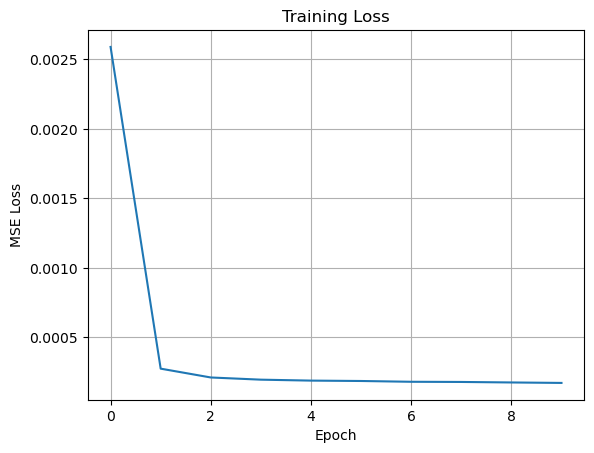

In [18]:
num_epochs = 10

loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for inputs, targets in loop:
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Crop targets to match output size
        targets_cropped = center_crop(targets, size=21)

        # Forward
        outputs = model(inputs)

        # Loss
        loss = criterion(outputs, targets_cropped)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.6f}")

# Plot training loss
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()

### Full Image Inference and evaluation

In [25]:
# Bilinear Demosaicing for baseline comparison

import torch.nn.functional as F

def bilinear_demosaic(mosaic):
    """
    Simple bilinear interpolation baseline
    mosaic: [1, 3, H, W]
    """
    B, C, H, W = mosaic.shape
    device = mosaic.device

    # Extract channels
    R = mosaic[:, 0:1]
    G = mosaic[:, 1:2]
    Bc = mosaic[:, 2:3]

    # Create coordinate grid
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    yy = yy.to(device)
    xx = xx.to(device)

    # Masks for Bayer pattern
    is_red   = (yy % 2 == 0) & (xx % 2 == 0)
    is_blue  = (yy % 2 == 1) & (xx % 2 == 1)
    is_green = ~ (is_red | is_blue)

    is_red   = is_red.unsqueeze(0).unsqueeze(0)
    is_blue  = is_blue.unsqueeze(0).unsqueeze(0)
    is_green = is_green.unsqueeze(0).unsqueeze(0)

    # Define kernels
    kernel_h = torch.tensor([[0,0,0],
                             [0.5,0,0.5],
                             [0,0,0]], device=device).view(1,1,3,3)

    kernel_v = torch.tensor([[0,0.5,0],
                             [0,0,0],
                             [0,0.5,0]], device=device).view(1,1,3,3)

    kernel_cross = torch.tensor([[0,0.25,0],
                                 [0.25,0,0.25],
                                 [0,0.25,0]], device=device).view(1,1,3,3)

    kernel_diag = torch.tensor([[0.25,0,0.25],
                                [0,0,0],
                                [0.25,0,0.25]], device=device).view(1,1,3,3)

    # Interpolate G everywhere
    G_interp = F.conv2d(G, kernel_cross, padding=1)
    G = torch.where(is_green, G, G_interp)

    # Interpolate R
    R_h = F.conv2d(R, kernel_h, padding=1)
    R_v = F.conv2d(R, kernel_v, padding=1)
    R_d = F.conv2d(R, kernel_diag, padding=1)

    R_interp = torch.zeros_like(R)
    R_interp = torch.where(is_green & (yy % 2 == 0).unsqueeze(0).unsqueeze(0), R_h, R_interp)
    R_interp = torch.where(is_green & (yy % 2 == 1).unsqueeze(0).unsqueeze(0), R_v, R_interp)
    R_interp = torch.where(is_blue, R_d, R_interp)

    R = torch.where(is_red, R, R_interp)

    # Interpolate B (symmetric to R)
    B_h = F.conv2d(Bc, kernel_h, padding=1)
    B_v = F.conv2d(Bc, kernel_v, padding=1)
    B_d = F.conv2d(Bc, kernel_diag, padding=1)

    B_interp = torch.zeros_like(Bc)
    B_interp = torch.where(is_green & (yy % 2 == 1).unsqueeze(0).unsqueeze(0), B_h, B_interp)
    B_interp = torch.where(is_green & (yy % 2 == 0).unsqueeze(0).unsqueeze(0), B_v, B_interp)
    B_interp = torch.where(is_red, B_d, B_interp)

    Bc = torch.where(is_blue, Bc, B_interp)

    return torch.cat([R, G, Bc], dim=1)

In [20]:
# Patch-wise Inference + Stitching

def demosaic_full_image(model, mosaic, patch_size=33, stride=10):
    """
    mosaic: [3, H, W]
    returns: reconstructed RGB image [3, H, W]
    """
    model.eval()

    _, H, W = mosaic.shape

    output = torch.zeros((3, H, W))
    weight = torch.zeros((3, H, W))

    mosaic = mosaic.unsqueeze(0).to(device)  # [1,3,H,W]

    with torch.no_grad():
        for i in range(0, H - patch_size + 1, stride):
            for j in range(0, W - patch_size + 1, stride):

                patch = mosaic[:, :, i:i+patch_size, j:j+patch_size] # extract a mosaic patch

                pred = model(patch)  # [1,3,21,21] # run the CNN model on it

                pred = pred.squeeze(0).cpu()

                # placement region (center of patch)
                start_i = i + 6   # (33 - 21)//2 = 6
                start_j = j + 6

                output[:, start_i:start_i+21, start_j:start_j+21] += pred
                weight[:, start_i:start_i+21, start_j:start_j+21] += 1

    # avoid division by zero
    weight[weight == 0] = 1
    output = output / weight

    return output.clamp(0, 1)

In [ ]:
# PSNR Function
def compute_psnr(img1, img2):
    """
    img1, img2: [3, H, W], values in [0,1]
    """
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

# The CNN-demosaic image has a black rim (each patch is reduced from 33x33 to 21x21)
# So we need to crop the valid region
def crop_valid_region(img, border):
    return img[:, border:-border, border:-border]

In [31]:
# Average PSNR on Test Set

psnr_cnn_list = []
psnr_bilinear_list = []

model.eval()

for idx in tqdm(range(len(test_base))):
    img, _ = test_base[idx]

    gt = img
    mosaic = bayer_mosaic(gt)

    # CNN
    cnn_out = demosaic_full_image(model, mosaic)

    # Bilinear
    bilinear_out = bilinear_demosaic(mosaic.unsqueeze(0)).squeeze(0)

    # Crop all images
    gt_crop = crop_valid_region(gt, border=26)
    cnn_crop = crop_valid_region(cnn_out, border=26)
    bilinear_crop = crop_valid_region(bilinear_out, border=26)

    # PSNR
    psnr_cnn = compute_psnr(cnn_crop, gt_crop)
    psnr_bilinear = compute_psnr(bilinear_crop, gt_crop)

    psnr_cnn_list.append(psnr_cnn.item())
    psnr_bilinear_list.append(psnr_bilinear.item())

100%|██████████| 200/200 [04:41<00:00,  1.41s/it]


In [32]:
avg_psnr_cnn = np.mean(psnr_cnn_list)
avg_psnr_bilinear = np.mean(psnr_bilinear_list)

print(f"Average PSNR (CNN): {avg_psnr_cnn:.2f} dB")
print(f"Average PSNR (Bilinear): {avg_psnr_bilinear:.2f} dB")

Average PSNR (CNN): 38.00 dB
Average PSNR (Bilinear): 28.54 dB


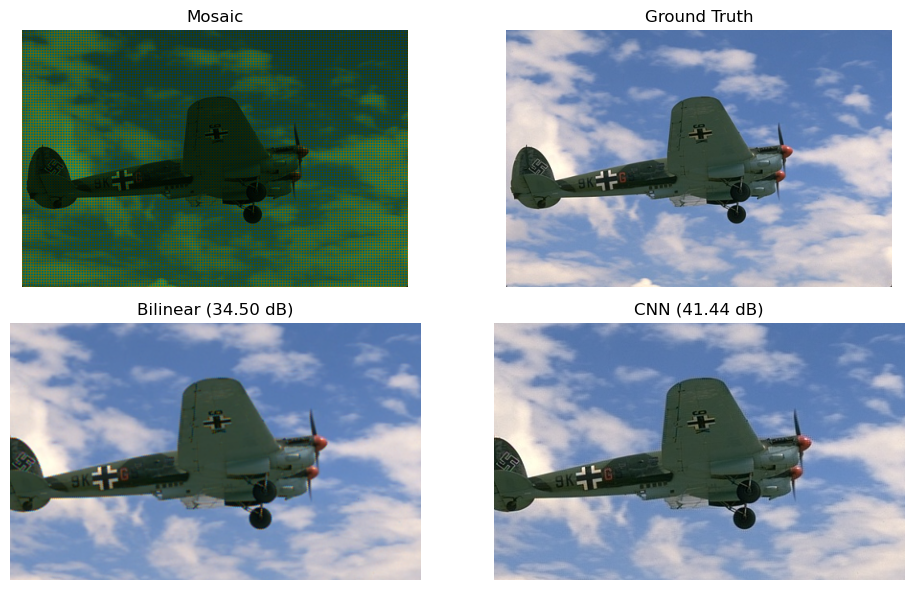

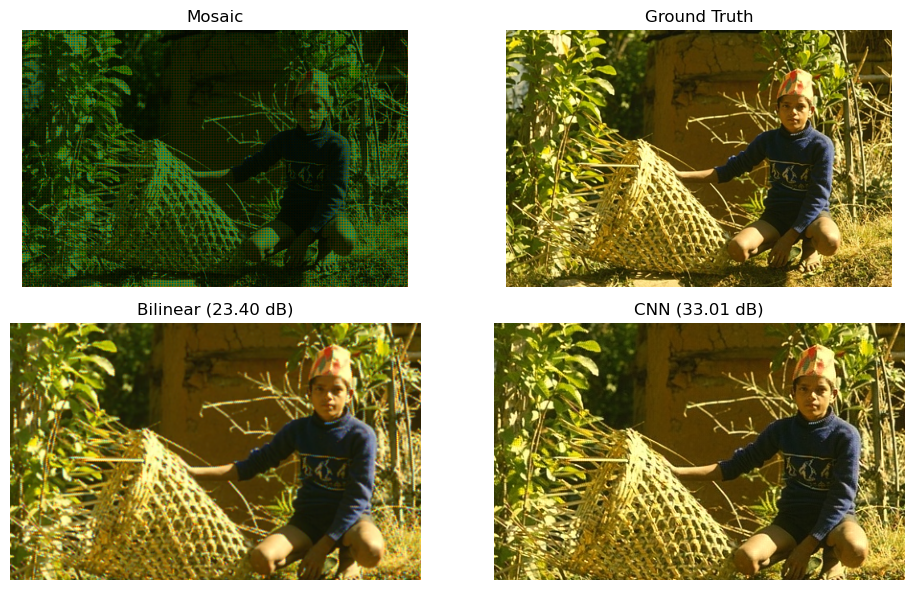

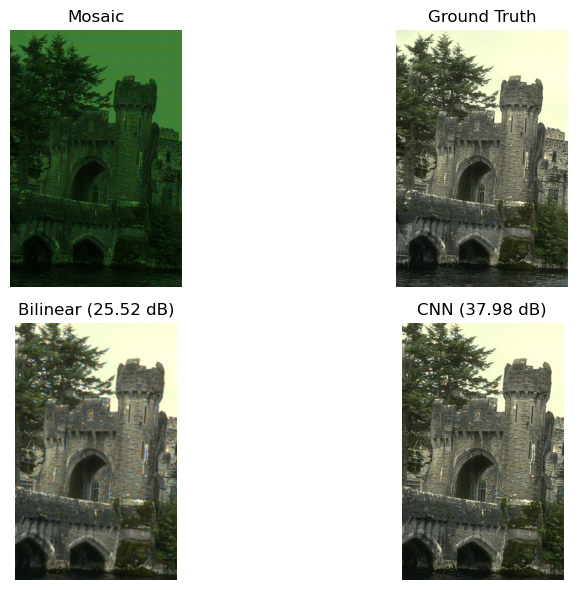

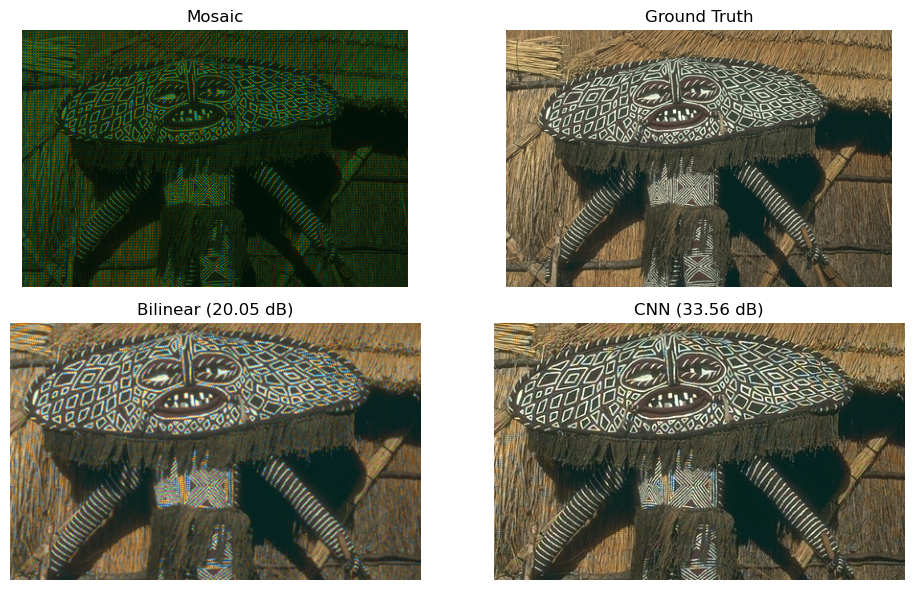

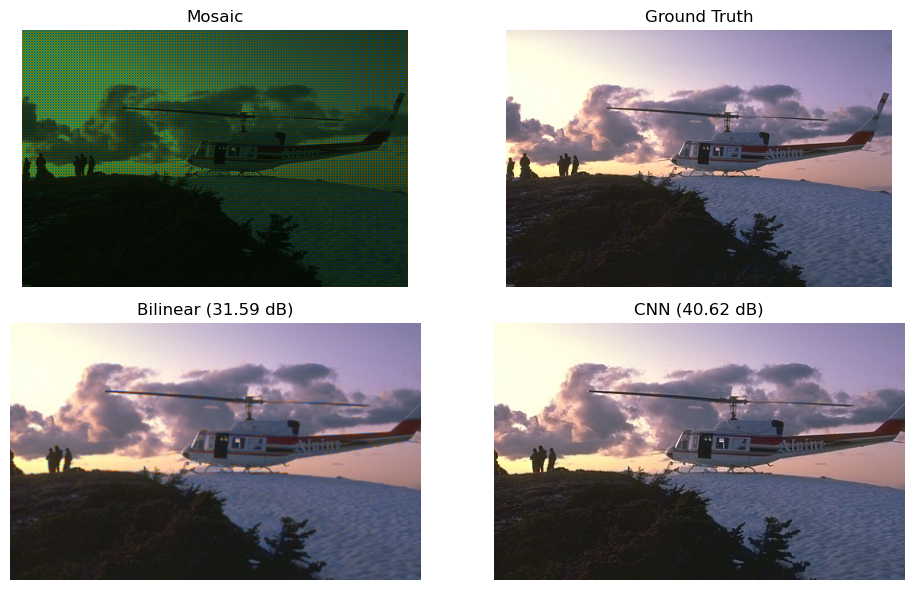

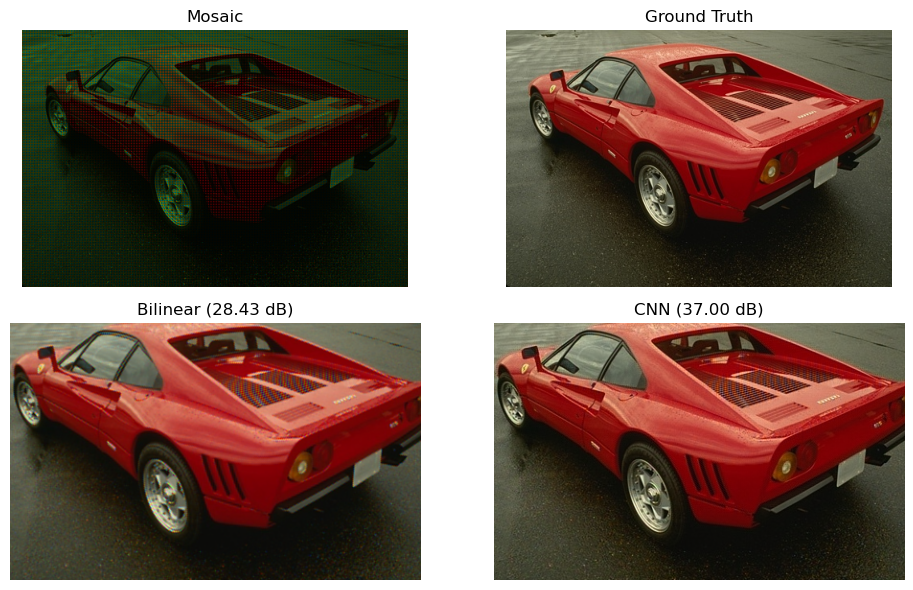

In [33]:
# Visualization

num_visuals = 6

indices = np.random.choice(len(test_base), num_visuals, replace=False)

for idx in indices:
    img, _ = test_base[idx]

    gt = img
    gt_crop = crop_valid_region(gt, border=26)
    mosaic = bayer_mosaic(gt)

    cnn_out = demosaic_full_image(model, mosaic)
    cnn_crop = crop_valid_region(cnn_out, border=26)
    bilinear_out = bilinear_demosaic(mosaic.unsqueeze(0)).squeeze(0)
    bilinear_crop = crop_valid_region(bilinear_out, border=26)

    psnr_cnn = compute_psnr(cnn_crop, gt_crop)
    psnr_bilinear = compute_psnr(bilinear_crop, gt_crop)

    plt.figure(figsize=(10, 6))

    plt.subplot(2,2,1)
    plt.imshow(mosaic.permute(1,2,0))
    plt.title("Mosaic")

    plt.subplot(2,2,2)
    plt.imshow(gt.permute(1,2,0))
    plt.title("Ground Truth")

    plt.subplot(2,2,3)
    plt.imshow(bilinear_crop.permute(1,2,0))
    plt.title(f"Bilinear ({psnr_bilinear:.2f} dB)")

    plt.subplot(2,2,4)
    plt.imshow(cnn_crop.permute(1,2,0))
    plt.title(f"CNN ({psnr_cnn:.2f} dB)")

    for i in range(1,5):
        plt.subplot(2,2,i).axis('off')

    plt.tight_layout()
    plt.show()